In [1]:
import os
from pathlib import Path
# =======================
# Simple KNN (close) + FPS (distant) Sampling + A1 (Spearman) — CSV + Plot
# =======================
from typing import List, Optional, Dict, Tuple
from scipy.spatial.distance import jensenshannon
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.stats import mannwhitneyu, wilcoxon
from tqdm import tqdm

# -----------------------
# Reproducibility knobs
# -----------------------
SEED_GLOBAL = 1234
K_SEEDS = 250          # number of seeds to sample per maze
M_PER_GROUP = 20       # group size (per seed) for both close and distant

# =============================================================================
# Config (absolute paths + environment)
# =============================================================================
REPO_ROOT = Path(os.getcwd()).resolve().parents[2]
print(REPO_ROOT)

# Avoid BLAS oversubscription under process parallelism
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# Experiment selection
MAZES = ['LM4', 'LM6', 'LM8', 'LM8D', 'LMO8', 'LMO8D', 'LM8_addition', 'LMO8_remove', 'BR']
MAZE_INDEX = 4  # LM8
MAZE_KEY = MAZES[MAZE_INDEX]

# Network sizes to evaluate
N_PCS_LIST = [10, 25, 50, 75, 100, 250, 500, 750]

# Output dir
OUT_DIR = REPO_ROOT / "data" / "results" / "spatial_encoding" / MAZE_KEY
OUT_DIR.mkdir(parents=True, exist_ok=True)

/Users/titonka/FAIRIS


In [2]:
def _pick_any_df_key(d: Dict[int, pd.DataFrame], preferred_order: Optional[List[int]] = None) -> int:
    if preferred_order:
        for k in preferred_order:
            if k in d:
                return k
    return sorted(d.keys())[0]

def load_xy_and_activations(repo_root: Path, maze_key: str) -> Tuple[np.ndarray, Dict[int, pd.DataFrame]]:
    """Load (x,y) once (from any available N), and the dict N -> DataFrame."""
    act_path = repo_root / "data" / "activations" / f"activations_{maze_key}.pkl"
    if not act_path.exists():
        raise FileNotFoundError(f"Missing activations file: {act_path}")
    with open(act_path, "rb") as fh:
        by_n: Dict[int, pd.DataFrame] = pickle.load(fh)
    n_key = _pick_any_df_key(by_n, preferred_order=N_PCS_LIST)
    df0 = by_n[n_key]
    if not {"x", "y"}.issubset(df0.columns):
        raise ValueError(f"(x,y) columns not found in activations dataframe for N={n_key}")
    xy = df0[["x", "y"]].to_numpy(dtype=np.float32)
    return xy, by_n



In [3]:
# =======================
# A1: Spearman(distance, cosine-sim(activations))
# =======================

# -----------------------------
# Helpers
# -----------------------------
def _upper_tri_flat(mat: np.ndarray, k: int = 1) -> np.ndarray:
    i, j = np.triu_indices_from(mat, k=k)
    return mat[i, j]

def pairwise_distances_xy(xy: np.ndarray) -> np.ndarray:
    """
    Pairwise Euclidean distances for positions (N,2) -> (N,N).
    """
    if xy.ndim != 2 or xy.shape[1] != 2:
        raise ValueError("xy must have shape (N, 2)")
    xx = np.sum(xy**2, axis=1, keepdims=True)
    d2 = xx + xx.T - 2 * (xy @ xy.T)
    d2[d2 < 0] = 0.0  # numerical guard
    return np.sqrt(d2, dtype=np.float64)

def cosine_similarity_matrix(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Pairwise cosine similarity between activation vectors (rows of A).
    """
    if A.ndim != 2:
        raise ValueError("A must have shape (N, K)")
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    norms = np.clip(norms, eps, None)
    A_unit = A / norms
    return A_unit @ A_unit.T

def _extract_activation_matrix(df: pd.DataFrame) -> np.ndarray:
    """
    Extract the activation columns from an activations DataFrame.

    Strategy:
      1) Prefer columns starting with 'pc_' if present.
      2) Else, take all numeric columns and drop common metadata columns.
    """
    # 1) 'pc_' convention
    pc_cols = [c for c in df.columns if str(c).startswith("pc_")]
    if pc_cols:
        return df[pc_cols].to_numpy(dtype=np.float64)

    # 2) Fallback: numeric columns excluding metadata
    meta = {"x", "y", "theta", "idx", "maze", "seed"}
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    act_cols = [c for c in num_cols if c not in meta]
    if not act_cols:
        raise ValueError("Could not find activation columns in DataFrame.")
    return df[act_cols].to_numpy(dtype=np.float64)

def _sample_upper_tri_indices(n: int, rng: np.random.Generator, max_pairs: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Randomly sample up to max_pairs indices from the upper triangle (k=1) of an (n x n) matrix.
    Returns (i_idx, j_idx) arrays of equal length.
    """
    iu, ju = np.triu_indices(n, k=1)
    m = iu.size
    if max_pairs is None or max_pairs >= m:
        return iu, ju
    sel = rng.choice(m, size=max_pairs, replace=False)
    return iu[sel], ju[sel]

# -----------------------------
# Core metric
# -----------------------------
def spearman_distance_vs_activation_similarity(
    xy: np.ndarray,
    A: np.ndarray,
    *,
    max_pairs: Optional[int] = None,
    seed: Optional[int] = None
) -> Tuple[float, float, int]:
    """
    Compute Spearman's rho between pairwise spatial distances and pairwise activation cosine similarities.

    Parameters
    ----------
    xy : (N, 2) array
    A  : (N, K) array
    max_pairs : int or None
        If set, randomly subsample this many pairs from the upper triangle to save time/memory.
    seed : int or None
        RNG seed for reproducible subsampling.

    Returns
    -------
    rho : float
    pval : float
    n_pairs : int  # number of pairs used in the correlation
    """
    if xy.shape[0] != A.shape[0]:
        raise ValueError("xy and A must have the same number of rows (N).")

    N = xy.shape[0]
    rng = np.random.default_rng(seed)

    # Pairwise distances and similarities
    D = pairwise_distances_xy(xy)       # (N,N)
    S = cosine_similarity_matrix(A)     # (N,N)

    # Optionally subsample pairs from the upper triangle
    if max_pairs is not None:
        iu, ju = _sample_upper_tri_indices(N, rng, max_pairs)
        dist_flat = D[iu, ju]
        sim_flat  = S[iu, ju]
    else:
        dist_flat = _upper_tri_flat(D, k=1)
        sim_flat  = _upper_tri_flat(S, k=1)

    # Drop invalid pairs (should be rare)
    mask = np.isfinite(dist_flat) & np.isfinite(sim_flat)
    dist_flat = dist_flat[mask]
    sim_flat  = sim_flat[mask]

    rho, pval = spearmanr(dist_flat, sim_flat)
    return float(rho), float(pval), int(dist_flat.size)

# -----------------------------
# Runner across all N (K place cells)
# -----------------------------
def run_A1_spearman_distance_similarity_for_all_N(
    repo_root: Path,
    maze_key: str,
    *,
    n_list: List[int],
    by_n: Dict[int, pd.DataFrame],
    xy: np.ndarray,
    out_dir: Path,
    max_pairs: Optional[int] = None,
    seed: Optional[int] = None
) -> pd.DataFrame:
    """
    Loop over all network sizes (N place cells) and compute Spearman(distance, cosine-sim(activations)).
    Saves a CSV and returns the summary DataFrame.
    """
    rows = []
    for n_pcs in n_list:
        if n_pcs not in by_n:
            # Skip if this K wasn't computed for this maze
            continue
        df = by_n[n_pcs]
        A = _extract_activation_matrix(df)
        rho, pval, n_pairs = spearman_distance_vs_activation_similarity(
            xy, A, max_pairs=max_pairs, seed=seed
        )
        rows.append({
            "maze": maze_key,
            "n_place_cells": n_pcs,
            "rho_spearman_dist_vs_cos": rho,
            "p_value": pval,
            "n_locations": int(xy.shape[0]),
            "n_pairs_used": n_pairs
        })

    result = pd.DataFrame(rows).sort_values("n_place_cells").reset_index(drop=True)
    out_path = out_dir / f"A1_spearman_distance_vs_cosine_{maze_key}.csv"
    result.to_csv(out_path, index=False)
    print(f"[A1] Wrote: {out_path}")
    return result


In [4]:
# Load once using your helper:
xy, by_n = load_xy_and_activations(REPO_ROOT, MAZE_KEY)

# Run across all configured K values; optionally subsample pairs for speed:
#   - Set max_pairs=None to use ALL pairs (O(N^2))
#   - Or set max_pairs=1_000_000 (for example) to limit runtime/memory
A1_df = run_A1_spearman_distance_similarity_for_all_N(
    REPO_ROOT,
    MAZE_KEY,
    n_list=N_PCS_LIST,
    by_n=by_n,
    xy=xy,
    out_dir=OUT_DIR,
    max_pairs=None,      # or None for all pairs
    seed=SEED_GLOBAL
)

A1_df


[A1] Wrote: /Users/titonka/FAIRIS/data/results/spatial_encoding/LMO8/A1_spearman_distance_vs_cosine_LMO8.csv


,maze,n_place_cells,rho_spearman_dist_vs_cos,p_value,n_locations,n_pairs_used
0,LMO8,10,-0.358852,0.0,3772,7112106
1,LMO8,25,-0.367369,0.0,3772,7112106
2,LMO8,50,-0.363552,0.0,3772,7112106
3,LMO8,75,-0.371255,0.0,3772,7112106
4,LMO8,100,-0.368373,0.0,3772,7112106
5,LMO8,250,-0.366135,0.0,3772,7112106
6,LMO8,500,-0.369577,0.0,3772,7112106
7,LMO8,750,-0.366986,0.0,3772,7112106


In [5]:
# =======================
# A2: Jensen–Shannon Distance vs. Spatial Distance
# =======================

# ---------------------------------------------
# Utilities (reuse Spearman helpers)
# ---------------------------------------------

def pairwise_jsd_matrix(A: np.ndarray) -> np.ndarray:
    """
    Compute pairwise Jensen–Shannon distances between all rows of A.
    Each row is normalized to a probability distribution.
    Returns an (N,N) symmetric matrix with entries in [0, 1].
    """
    A = np.clip(A, 1e-12, None)
    P = A / A.sum(axis=1, keepdims=True)
    N = P.shape[0]
    J = np.zeros((N, N), dtype=np.float64)
    for i in range(N):
        for j in range(i+1, N):
            J[i, j] = J[j, i] = jensenshannon(P[i], P[j])
    return J


# ---------------------------------------------
# Core metric: correlation between JSD and distance
# ---------------------------------------------
def jsd_distance_correlation(
    xy: np.ndarray,
    A: np.ndarray,
    *,
    max_pairs: Optional[int] = None,
    seed: Optional[int] = None
) -> Tuple[float, float, int]:
    """
    Compute Spearman's correlation between pairwise spatial distance
    and pairwise Jensen–Shannon distance.
    """
    if xy.shape[0] != A.shape[0]:
        raise ValueError("xy and A must have the same number of rows (N).")

    N = xy.shape[0]
    rng = np.random.default_rng(seed)

    # Compute pairwise distances and JSD
    D = pairwise_distances_xy(xy)
    J = pairwise_jsd_matrix(A)

    iu, ju = np.triu_indices(N, k=1)
    if max_pairs is not None and len(iu) > max_pairs:
        sel = rng.choice(len(iu), size=max_pairs, replace=False)
        iu, ju = iu[sel], ju[sel]

    dist_flat = D[iu, ju]
    jsd_flat  = J[iu, ju]

    mask = np.isfinite(dist_flat) & np.isfinite(jsd_flat)
    dist_flat = dist_flat[mask]
    jsd_flat  = jsd_flat[mask]

    rho, pval = spearmanr(dist_flat, jsd_flat)
    return float(rho), float(pval), int(dist_flat.size)

# ---------------------------------------------
# Runner across all network sizes
# ---------------------------------------------
def run_A2_jsd_distance_correlation_for_all_N(
    repo_root: Path,
    maze_key: str,
    *,
    n_list: List[int],
    by_n: Dict[int, pd.DataFrame],
    xy: np.ndarray,
    out_dir: Path,
    max_pairs: Optional[int] = None,
    seed: Optional[int] = None
) -> pd.DataFrame:
    """
    Loop over all network sizes (K place cells) and compute correlation
    between pairwise spatial distance and Jensen–Shannon distance.
    Saves CSV and returns the summary DataFrame.
    """
    rows = []
    for n_pcs in tqdm(n_list, desc=f"A2 JSD {maze_key}"):
        if n_pcs not in by_n:
            continue
        df = by_n[n_pcs]
        A = _extract_activation_matrix(df)
        rho, pval, n_pairs = jsd_distance_correlation(
            xy, A, max_pairs=max_pairs, seed=seed
        )
        rows.append({
            "maze": maze_key,
            "n_place_cells": n_pcs,
            "rho_jsd_vs_distance": rho,
            "p_value": pval,
            "n_locations": int(xy.shape[0]),
            "n_pairs_used": n_pairs
        })

    result = pd.DataFrame(rows).sort_values("n_place_cells").reset_index(drop=True)
    out_path = out_dir / f"A2_jsd_distance_correlation_{maze_key}.csv"
    result.to_csv(out_path, index=False)
    print(f"[A2] Wrote: {out_path}")
    return result


In [7]:
xy, by_n = load_xy_and_activations(REPO_ROOT, MAZE_KEY)

A2_df = run_A2_jsd_distance_correlation_for_all_N(
    REPO_ROOT,
    MAZE_KEY,
    n_list=N_PCS_LIST,
    by_n=by_n,
    xy=xy,
    out_dir=OUT_DIR,
    max_pairs=100,   # optional subsampling for large N
    seed=SEED_GLOBAL
)

A2_df


A2 JSD LMO8: 100%|██████████| 8/8 [29:32<00:00, 221.56s/it]

[A2] Wrote: /Users/titonka/FAIRIS/data/results/spatial_encoding/LMO8/A2_jsd_distance_correlation_LMO8.csv


,maze,n_place_cells,rho_jsd_vs_distance,p_value,n_locations,n_pairs_used
0,LMO8,10,0.515116,4.169947e-08,3772,100
1,LMO8,25,0.530969,1.324132e-08,3772,100
2,LMO8,50,0.532649,1.168476e-08,3772,100
3,LMO8,75,0.531365,1.285748e-08,3772,100
4,LMO8,100,0.539298,7.075681e-09,3772,100
5,LMO8,250,0.531317,1.290344e-08,3772,100
6,LMO8,500,0.534593,1.010189e-08,3772,100
7,LMO8,750,0.534257,1.035995e-08,3772,100


In [8]:
# ---------------------------------------------
# Helper functions
# ---------------------------------------------
def _extract_activation_matrix(df: pd.DataFrame) -> np.ndarray:
    """
    Extract activation matrix (K columns per place cell).
    """
    pc_cols = [c for c in df.columns if str(c).startswith("pc_")]
    if pc_cols:
        return df[pc_cols].to_numpy(dtype=np.float64)
    meta = {"x", "y", "theta", "idx", "maze", "seed"}
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    act_cols = [c for c in num_cols if c not in meta]
    if not act_cols:
        raise ValueError("Could not find activation columns in DataFrame.")
    return df[act_cols].to_numpy(dtype=np.float64)

def shannon_entropy_matrix(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute Shannon entropy (bits) for each activation vector (row).
    A: (N, K) activation matrix.
    Returns: (N,) array of entropy values.
    """
    A = np.clip(A, eps, None)
    P = A / A.sum(axis=1, keepdims=True)
    H = -np.sum(P * np.log2(P), axis=1)
    return H

# ---------------------------------------------
# Core computation and CSV writer
# ---------------------------------------------
def run_A3_shannon_entropy_for_all_N(
    repo_root: Path,
    maze_key: str,
    *,
    n_list: List[int],
    by_n: Dict[int, pd.DataFrame],
    out_dir: Path
) -> pd.DataFrame:
    """
    Compute Shannon entropy across all locations for each network size (K place cells).
    Returns a DataFrame with mean, median, and std, and writes it to CSV.
    """
    rows = []
    entropy_data = {}

    for n_pcs in tqdm(n_list, desc=f"A3 Entropy {maze_key}"):
        if n_pcs not in by_n:
            continue
        df = by_n[n_pcs]
        A = _extract_activation_matrix(df)
        H = shannon_entropy_matrix(A)

        rows.append({
            "maze": maze_key,
            "n_place_cells": n_pcs,
            "mean_entropy": np.mean(H),
            "median_entropy": np.median(H),
            "std_entropy": np.std(H),
            "n_locations": H.size
        })
        entropy_data[n_pcs] = H

    result = pd.DataFrame(rows).sort_values("n_place_cells").reset_index(drop=True)
    out_path = out_dir / f"A3_entropy_summary_{maze_key}.csv"
    result.to_csv(out_path, index=False)
    print(f"[A3] Wrote: {out_path}")
    return result, entropy_data

In [9]:
def plot_entropy_boxplot(entropy_data: Dict[int, np.ndarray], maze_key: str, out_dir: Path):
    """
    Create and save a box plot of entropy distributions for each network size.
    """
    plt.figure(figsize=(10, 5))
    ks = sorted(entropy_data.keys())
    data = [entropy_data[k] for k in ks]

    plt.boxplot(
        data,
        labels=ks,
        patch_artist=True,
        boxprops=dict(facecolor="lightsteelblue", color="black"),
        medianprops=dict(color="firebrick", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black")
    )
    plt.xlabel("Number of Place Cells (K)")
    plt.ylabel("Shannon Entropy (bits)")
    plt.title(f"Distribution of Entropy per Network Size — {maze_key}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    out_path = out_dir / f"A3_entropy_boxplot_{maze_key}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print(f"[A3] Saved boxplot: {out_path}")


A3 Entropy LMO8: 100%|██████████| 8/8 [00:00<00:00, 63.84it/s]

[A3] Wrote: /Users/titonka/FAIRIS/data/results/spatial_encoding/LMO8/A3_entropy_summary_LMO8.csv


,maze,n_place_cells,mean_entropy,median_entropy,std_entropy,n_locations
0,LMO8,10,3.137351,3.156702,0.100288,3772
1,LMO8,25,4.450156,4.468757,0.102006,3772
2,LMO8,50,5.417691,5.440018,0.109283,3772
3,LMO8,75,5.971059,6.001376,0.122577,3772
4,LMO8,100,6.357980,6.387351,0.127453,3772
5,LMO8,250,7.531763,7.567858,0.158133,3772
6,LMO8,500,8.244146,8.295117,0.210488,3772
7,LMO8,750,8.377410,8.431041,0.264470,3772


/var/folders/k9/tcxpg_fx3d3blrkql_1z83wh0000gn/T/ipykernel_2616/2734261351.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


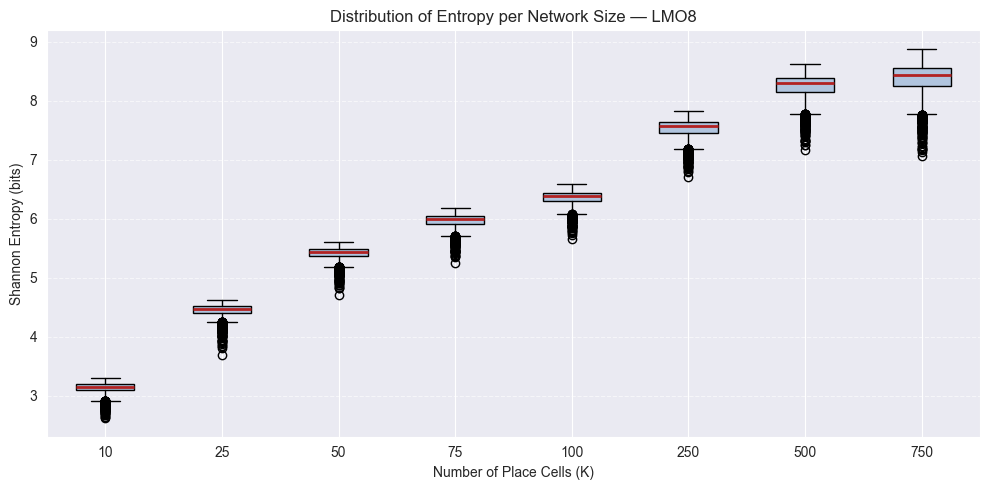

[A3] Saved boxplot: /Users/titonka/FAIRIS/data/results/spatial_encoding/LMO8/A3_entropy_boxplot_LMO8.png


In [10]:
xy, by_n = load_xy_and_activations(REPO_ROOT, MAZE_KEY)

A3_df, entropy_data = run_A3_shannon_entropy_for_all_N(
    REPO_ROOT,
    MAZE_KEY,
    n_list=N_PCS_LIST,
    by_n=by_n,
    out_dir=OUT_DIR
)

display(A3_df)

plot_entropy_boxplot(entropy_data, MAZE_KEY, OUT_DIR)
